## **AVANCE 1 DEL PROYECTO**

INICIALMENTE LA FUENTE DE DATOS SE ENCONTRARON DISTRIBUIDOS EN FIFERENYTES TABLAS

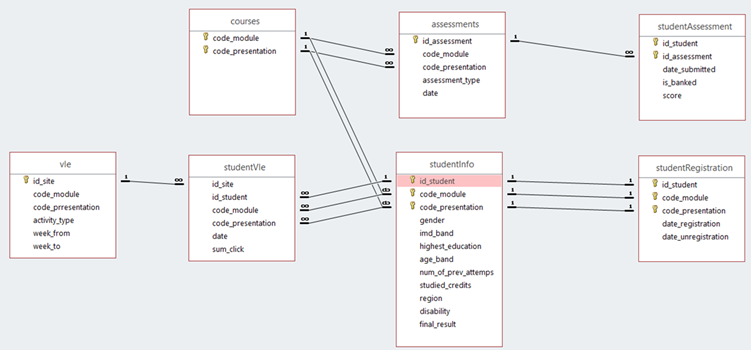

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ──────────────────────────────────────────────────────────────
# BLOQUE 0 — INTEGRAR LOS 7 ARCHIVOS CSV EN UN SOLO DATASET
# import pandas as pd

# PRUEBA DE UNIR DOS ARCHIVOS DATASETS
# 1. Cargar los dataset courses y assessments
courses = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/courses.csv')
assessments = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/assessments.csv')

# 2. Realizar el merge usando las dos columnas clave
# Usamos code_module y code_presentation' como la combinación para identificar de forma única a un curso en un periodo específico.
evaluaciones_enriquecidas = assessments.merge(courses,
                             on=['code_module', 'code_presentation'],
                             how='left')
# 3. Mostrar las primeras filas del resultado
evaluaciones_enriquecidas .head()


# ==============================================================================
# PASO 1: INTEGRAR LOS 7 ARCHIVOS SCV CON MERGE
# ==============================================================================
courses = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/courses.csv')
assessments = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/assessments.csv')
studentInfo = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/studentInfo.csv')
studentRegistration = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/studentRegistration.csv')
studentVle = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/studentVle.csv')
vle = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/vle.csv')
studentAssessment = pd.read_csv('/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/studentAssessment.csv')

# ==============================================================================
# PASO 2: AGREGACIÓN DE LA TABLA DE CALIFICACIONES (studentAssessment + assessments)
# ==============================================================================
student_ass_merged = pd.merge(studentAssessment, assessments, on='id_assessment', how='inner')
student_ass_merged['weighted_score'] = (student_ass_merged['score'] * student_ass_merged['weight']) / 100

student_perf = student_ass_merged.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_assessments_submitted=('id_assessment', 'count'),
    average_score=('score', 'mean'),
    total_weighted_score=('weighted_score', 'sum')
).reset_index()

# ==============================================================================
# PASO 3: AGREGACIÓN DE LAS TRAZAS DE APRENDIZAJE / CLICS (studentVle)
# ==============================================================================
student_clicks = studentVle.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    unique_days_active=('date', 'nunique')
).reset_index()

# ==============================================================================
# PASO 4: INTEGRACIÓN CENTRAL (LEFT JOIN DESDE LA TABLA MAESTRA)
# ==============================================================================
final_df = studentInfo.copy()

final_df = pd.merge(final_df, studentRegistration, on=['id_student', 'code_module', 'code_presentation'], how='left')
final_df = pd.merge(final_df, courses, on=['code_module', 'code_presentation'], how='left')
final_df = pd.merge(final_df, student_perf, on=['id_student', 'code_module', 'code_presentation'], how='left')
final_df = pd.merge(final_df, student_clicks, on=['id_student', 'code_module', 'code_presentation'], how='left')

# ==============================================================================
# PASO 5: TRATAMIENTO DE VALORES NULOS
# ==============================================================================
final_df['total_clicks'] = final_df['total_clicks'].fillna(0)
final_df['unique_days_active'] = final_df['unique_days_active'].fillna(0)
final_df['total_assessments_submitted'] = final_df['total_assessments_submitted'].fillna(0)
final_df['average_score'] = final_df['average_score'].fillna(0)
final_df['total_weighted_score'] = final_df['total_weighted_score'].fillna(0)

# ==============================================================================
# PASO 6: GUARDAR EL ARCHIVO CONSOLIDADO DIRECTAMENTE EN TU DRIVE
# De esta manera el resultado final quedará guardado para siempre en tu Drive.
# ==============================================================================
# Definimos la ruta base de la carpeta
carpeta_data = "/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/"

# Usamos la f-string correctamente apuntando a la variable
output_path = f"{carpeta_data}consolidado_1.csv"
final_df.to_csv(output_path, index=False)


In [ ]:
# ──────────────────────────────────────────────────────────────
# BLOQUE 1 — Carga del dataset original
# ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# EQUIPO: reemplaza con la ruta real de tu dataset fuente
RUTA_DATASET_ORIGINAL = '/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/consolidado_1.csv'

# NOTA: si tu archivo usa separador TAB (ej. marketing_campaign.csv de Kaggle):
# df_original = pd.read_csv(RUTA_DATASET_ORIGINAL, sep='\t')
df_original = pd.read_csv(RUTA_DATASET_ORIGINAL)
print('Dataset original cargado:')
print(f'  Filas: {df_original.shape[0]}')
print(f'  Columnas: {df_original.shape[1]}')
df_original.head(3)

Dataset original cargado:
  Filas: 32593
  Columnas: 20


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,268,5.0,82.0,82.4,934.0,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,-53.0,NaN,268,5.0,66.4,65.4,1435.0,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,-92.0,12.0,268,0.0,0.0,0.0,281.0,12.0


**[EQUIPO — completar] Documentación del dataset fuente:**  
- **Nombre:** Open University Learning Analytics Dataset
- **Fuente:** https://www.kaggle.com/datasets/rocki37/open-university-learning-analytics-dataset
- **Fecha de descarga/acceso:** 10/06/2026
- **Descripción:** El dataset contiene informacion de rastros de los estudiantes al interactuar con una plataforma LMS (Learning Manager System). EL proposito es analizar la informacion y encontrar patrones de comportamiento   
- **Pregunta de decisión del equipo:** ¿Es posible predecir el result_final de un estudiante?

In [ ]:
# ──────────────────────────────────────────────────────────────
# BLOQUE 2 — Diagnóstico de calidad inicial
# ──────────────────────────────────────────────────────────────
print('=== DIAGNÓSTICO DE CALIDAD ===')
print(f'Dimensiones: {df_original.shape}')
print()
print('Tipos de datos:')
print(df_original.dtypes)
print()
print('Nulos por columna:')
nulos = df_original.isnull().sum()
pct_nulos = (df_original.isnull().mean() * 100).round(2)
diagnostico_nulos = pd.DataFrame({'nulos': nulos, 'pct': pct_nulos})
print(diagnostico_nulos[diagnostico_nulos['nulos'] > 0])
print()
print(f'Duplicados: {df_original.duplicated().sum()}')

=== DIAGNÓSTICO DE CALIDAD ===
Dimensiones: (32593, 20)

Tipos de datos:
code_module                     object
code_presentation               object
id_student                       int64
gender                          object
region                          object
highest_education               object
imd_band                        object
age_band                        object
num_of_prev_attempts             int64
studied_credits                  int64
disability                      object
final_result                    object
date_registration              float64
date_unregistration            float64
module_presentation_length       int64
total_assessments_submitted    float64
average_score                  float64
total_weighted_score           float64
total_clicks                   float64
unique_days_active             float64
dtype: object

Nulos por columna:
                     nulos    pct
imd_band              1111   3.41
date_registration       45   0.14
date_unregi

In [ ]:
def reporte_calidad(df, nombre='dataset'):
    """Consolida los cuatro indicadores del protocolo diagnostico."""
    sep = '=' * 60
    lin = '-' * 60
    print(sep)
    print(f'REPORTE DE CALIDAD: {nombre}')
    print(sep)
    print(f'Shape        : {df.shape}')
    print(f'Columnas     : {df.shape[1]}')
    print(lin)

    nulos = df.isnull().sum()
    nulos_presentes = nulos[nulos > 0]
    if len(nulos_presentes) > 0:
        print('NULOS:')
        for col, n in nulos_presentes.items():
            pct = n / len(df) * 100
            print(f'  {col:<15}: {n:>4} ({pct:>6.2f}%)')
    else:
        print('NULOS        : ninguno')
    print(lin)

    n_dup = df.duplicated().sum()
    print(f'DUPLICADOS   : {n_dup} filas')
    print(lin)

    print('TIPOS (columnas con posible problema):')
    for col in df.columns:
        if df[col].dtype == 'object':
            nu = df[col].nunique()
            if nu < 25:
                print(f'  {col:<15}: object  (posible: category, {nu} valores distintos)')
            else:
                print(f'  {col:<15}: object  (verificar si es texto o fecha)')
    print(sep)

# Mostrar el reporte de calidad del dataset del grupo
reporte_calidad(df_original, nombre='consolidado_1.csv')

REPORTE DE CALIDAD: consolidado_1.csv
Shape        : (32593, 20)
Columnas     : 20
------------------------------------------------------------
NULOS:
  imd_band       : 1111 (  3.41%)
  date_registration:   45 (  0.14%)
  date_unregistration: 22521 ( 69.10%)
------------------------------------------------------------
DUPLICADOS   : 0 filas
------------------------------------------------------------
TIPOS (columnas con posible problema):
  code_module    : object  (posible: category, 7 valores distintos)
  code_presentation: object  (posible: category, 4 valores distintos)
  gender         : object  (posible: category, 2 valores distintos)
  region         : object  (posible: category, 13 valores distintos)
  highest_education: object  (posible: category, 5 valores distintos)
  imd_band       : object  (posible: category, 10 valores distintos)
  age_band       : object  (posible: category, 3 valores distintos)
  disability     : object  (posible: category, 2 valores distintos)
  fina

**[EQUIPO — completar] Reporte de calidad:**  
| Columna | Problema detectado | Severidad (Alta/Media/Baja) |  
|---|---|---|  
| _nombre_ | _nulos, tipo incorrecto, etc._ | _nivel_ |  

Antes de la limpieza, el dataset presenta un estado general aceptable, ya que contiene 32 593 registros y 20 columnas sin filas duplicadas.
Sin embargo, existen valores nulos en algunas variables, especialmente en date_unregistration, que concentra un alto porcentaje de datos faltantes.
También se observan columnas tipo object que representan variables categóricas, por lo que sería necesario ajustar sus tipos de datos.
En general, el dataset puede ser utilizado para análisis, pero requiere tratamiento de nulos y optimización de variables antes de continuar._

In [ ]:
# ──────────────────────────────────────────────────────────────
# BLOQUE 3 — Pipeline de limpieza (de S06)
# ──────────────────────────────────────────────────────────────
df_limpio = df_original.copy()
# EQUIPO: copia o reconstruye aquí el pipeline de limpieza de S06
# Ejemplo de estructura (adapta a tu dataset):

# Manejo de nulos de la Columna date_registration
# Encontrar el valor mínimo (el negativo más grande, ej. -300). Estos alumnos en su mayoria ha desaprobado y como resultado final del modulo se hna retirado
minimo_registro = df_limpio['date_registration'].min()
df_limpio['date_registration'] = df_limpio['date_registration'].fillna(minimo_registro)


# Manejo de nulos de la columna categorica imd_band
# En esta columna hay algunas celdas que contiene fecha como dia, meas y año. El cual no es un error, solo que se cambio el formato al integrar todas las tablas en una sola
# Por ejemplo si aparece una fecha: 10 de octubre o 20 de octubr es por "10-20"
df_limpio['imd_band'] = df_limpio['imd_band'].replace('10-20', '10-20%')
# Columna imd_band valores faltantes 1111 el cual equivale al 3.41%. Es un valor por debajo del umbral crítico del 5%.
moda_imd_band = df_limpio['imd_band'].mode()[0]
df_limpio['imd_band'] = df_limpio['imd_band'].fillna(moda_imd_band)


# Manejo de nulos de la columna date_unregistration
# En el contexto de la Open University, un valor nulo (NaN) en date_unregistration significa que el estudiante siguió activo y nunca canceló su matrícula. No es un error, es un dato valioso.
# No se puede rellenar con la moda o la media ya que destruiría el significado real del dato

# Al que terminó el curso (Pass, Distinction, Fail) y tiene NaN, le asignamos la duración de su módulo
condicion_completo = (df_limpio['date_unregistration'].isna()) & (df_limpio['final_result'] != 'Withdrawn')
df_limpio.loc[condicion_completo, 'date_unregistration'] = df_limpio['module_presentation_length']

# Si queda algún NaN que sí se retiró (Withdrawn), le ponemos la mediana de días de retiro
mediana_retiro = df_limpio[df_limpio['final_result'] == 'Withdrawn']['date_unregistration'].median()
df_limpio['date_unregistration'] = df_limpio['date_unregistration'].fillna(mediana_retiro)


# NO HAY NULOS
print('Nulos restantes:')
print(df_limpio.isnull().sum())

# NO HAY DUPLICADOS EN EL DATASET
n_antes = len(df_limpio)
df_ref = df_limpio.drop_duplicates()
n_despues = len(df_limpio)


# CORRECION DE TIPOS DE DATOS
# Convertir las columnas identificadas de tipo float a entero (int)
columnas_enteros = [
    'date_registration',
    'date_unregistration',
    'total_assessments_submitted',
    'total_clicks',
    'unique_days_active'
]
# Convertir las columnas numéricas identificadas a tipo entero
df_limpio[columnas_enteros] = df_limpio[columnas_enteros].astype(int)

# Definir la lista de columnas categóricas para optimizar memoria
columnas_categoricas = [
    'code_module', 'code_presentation', 'gender', 'region',
    'highest_education', 'imd_band', 'age_band', 'disability', 'final_result'
]

# Convertir todas las columnas de la lista a tipo 'category' en un solo paso
df_limpio[columnas_categoricas] = df_limpio[columnas_categoricas].astype('category')

# Verificando los tipos de datos
# df_limpio.dtypes


# ESTANDARIZAR EL NOMBRE DE LAS VARIABLES A SNAKE_CASE CON RENAME
# El nombres de las columnas(variables) ya enconytraba en notacion snake_case

# CONVERTIR EL TEXTO A MINUSCULA Y QUITAR LOS ESPACIOS ANTES Y DESPUES
# Seleccionamos automáticamente todas las columnas categóricas y de texto (object)
columnas_texto = df_limpio.select_dtypes(include=['object', 'category']).columns

# Recorremos cada columna, limpiamos los espacios, pasamos a minúsculas y aseguramos el formato
for col in columnas_texto:
    df_limpio[col] = (df_ref[col]
                   .astype(str)           # Convertimos temporalmente a texto para poder limpiar
                   .str.strip()           # Eliminamos espacios al inicio y al final
                   .str.lower()           # Pasamos todo a minúsculas
                   .astype('category'))   # Lo devolvemos a tipo 'category' optimizado


Nulos restantes:
code_module                    0
code_presentation              0
id_student                     0
gender                         0
region                         0
highest_education              0
imd_band                       0
age_band                       0
num_of_prev_attempts           0
studied_credits                0
disability                     0
final_result                   0
date_registration              0
date_unregistration            0
module_presentation_length     0
total_assessments_submitted    0
average_score                  0
total_weighted_score           0
total_clicks                   0
unique_days_active             0
dtype: int64


In [ ]:
print(df_limpio.dtypes)
df_limpio.head()

code_module                    category
code_presentation              category
id_student                        int64
gender                         category
region                         category
highest_education              category
imd_band                       category
age_band                       category
num_of_prev_attempts              int64
studied_credits                   int64
disability                     category
final_result                   category
date_registration                 int64
date_unregistration               int64
module_presentation_length        int64
total_assessments_submitted       int64
average_score                   float64
total_weighted_score            float64
total_clicks                      int64
unique_days_active                int64
dtype: object


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
0,aaa,2013j,11391,m,east anglian region,he qualification,90-100%,55<=,0,240,n,pass,-159,268,268,5,82.0,82.4,934,40
1,aaa,2013j,28400,f,scotland,he qualification,20-30%,35-55,0,60,n,pass,-53,268,268,5,66.4,65.4,1435,80
2,aaa,2013j,30268,f,north western region,a level or equivalent,30-40%,35-55,0,60,y,withdrawn,-92,12,268,0,0.0,0.0,281,12
3,aaa,2013j,31604,f,south east region,a level or equivalent,50-60%,35-55,0,60,n,pass,-52,268,268,5,76.0,76.3,2158,123
4,aaa,2013j,32885,f,west midlands region,lower than a level,50-60%,0-35,0,60,n,pass,-176,268,268,5,54.4,55.0,1034,70


**[EQUIPO — completar] Justificación técnica de cada decisión de limpieza:**  
| Columna | Problema | Estrategia | Justificación |  
|---|---|---|---|  
| _nombre_ | _nulos_ | _fillna(median)_ | _La mediana es robusta frente a outliers presentes en..._ |  

_Completa una fila por cada decisión de limpieza aplicada._

| Columna                       | Problema                        | Estrategia                                       | Justificación                                                                                                                                                                                                            |
| ----------------------------- | ------------------------------- | ------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `imd_band`                    | Valores nulos                   | `fillna('desconocido')`                          | Se completaron los nulos con una categoría adicional porque `imd_band` representa rangos socioeconómicos. Esto evita eliminar registros y permite conservar la información del estudiante aunque no se conozca su banda. |
| `date_registration`           | Valores nulos                   | `fillna(median)`                                 | Se usó la mediana porque es una medida robusta frente a valores extremos. Esta variable representa días relativos a la inscripción, por lo que mantenerla como numérica permite analizar la anticipación de matrícula.   |
| `date_unregistration`         | Muchos valores nulos            | `fillna(module_presentation_length)`             | Los nulos probablemente corresponden a estudiantes que no se retiraron del curso. Por eso se reemplazaron con la duración del módulo, indicando que permanecieron hasta el final.                                        |
| `code_module`                 | Tipo `object`                   | `astype('category')`                             | Se convirtió a categoría porque representa códigos de módulos con pocos valores distintos. Esto optimiza memoria y facilita agrupaciones por curso.                                                                      |
| `code_presentation`           | Tipo `object`                   | `astype('category')`                             | Se convirtió a categoría porque identifica el periodo o presentación del curso. Al tener pocos valores únicos, no requiere tratarse como texto libre.                                                                    |
| `gender`                      | Tipo `object`                   | `astype('category')`                             | Se transformó en categoría porque contiene valores cualitativos limitados. Esto permite comparar resultados según género de forma más eficiente.                                                                         |
| `region`                      | Tipo `object`                   | `astype('category')`                             | Se convirtió a categoría porque representa regiones geográficas. Esta transformación facilita análisis agrupados por zona.                                                                                               |
| `highest_education`           | Tipo `object`                   | `astype('category')`                             | Se convirtió a categoría porque corresponde al nivel educativo previo del estudiante. Es una variable cualitativa útil para segmentar el rendimiento académico.                                                          |
| `age_band`                    | Tipo `object`                   | `astype('category')`                             | Se transformó a categoría porque la edad está agrupada en rangos, no en valores numéricos continuos. Esto permite comparar el desempeño por grupos etarios.                                                              |
| `disability`                  | Tipo `object`                   | `astype('category')`                             | Se convirtió a categoría porque es una variable cualitativa binaria. Facilita el análisis comparativo entre estudiantes con y sin discapacidad.                                                                          |
| `final_result`                | Tipo `object`                   | `astype('category')`                             | Se convirtió a categoría porque representa el resultado final del estudiante: `pass`, `fail`, `withdrawn` o `distinction`. Es una variable objetivo para el análisis.                                                    |
| `average_score`               | Valores numéricos con decimales | `astype('float')`                                | Se mantuvo como decimal porque representa promedios de notas. Esto permite realizar cálculos estadísticos como media, comparación y agrupaciones.                                                                        |
| `total_weighted_score`        | Valores numéricos con decimales | `astype('float')`                                | Se mantuvo como decimal porque corresponde a un puntaje ponderado. Este tipo de dato es adecuado para cálculos de rendimiento académico.                                                                                 |
| `num_of_prev_attempts`        | Variable numérica discreta      | `astype('int')`                                  | Se mantuvo como entero porque representa la cantidad de intentos previos del estudiante. Permite analizar la relación entre repetición y resultado final.                                                                |
| `studied_credits`             | Variable numérica               | `astype('int')`                                  | Se mantuvo como entero porque representa créditos matriculados o estudiados. Es útil para análisis cuantitativos sobre carga académica.                                                                                  |
| `total_assessments_submitted` | Variable numérica discreta      | `astype('int')`                                  | Se mantuvo como entero porque indica el número de evaluaciones entregadas. Es una medida importante de participación académica.                                                                                          |
| `total_clicks`                | Variable numérica discreta      | `astype('int')`                                  | Se mantuvo como entero porque representa el total de interacciones en Moodle. Sirve para medir participación en el entorno virtual.                                                                                      |
| `unique_days_active`          | Variable numérica discreta      | `astype('int')`                                  | Se mantuvo como entero porque mide los días activos únicos en Moodle. Es clave para analizar la constancia del estudiante.                                                                                               |
| Dataset completo              | Posibles duplicados             | `drop_duplicates()` / verificación de duplicados | Se verificó la existencia de filas repetidas. Como el resultado fue 0 duplicados, no fue necesario eliminar registros, lo que indica buena integridad del dataset.                                                       |


In [ ]:
# ──────────────────────────────────────────────────────────────
# BLOQUE 4 — Transformaciones y variables derivadas
# ──────────────────────────────────────────────────────────────

# EQUIPO: crea las variables derivadas relevantes para tu análisis
# VARIABLE age_band.
# Al plicar uniquezz
df_limpio['age_band'].unique()
# Los resultados son ['0-35', '35-55', '55<='], ademas que la ultima etiqueta esta en orden inverso, el cual es un error
# Definir el nuevo mapeo con las etiquetas corregidas y con mejor significado
mapeo_edades = {
    '0-35': 'menor o igual a 35 años',
    '35-55': 'entre 35 y 55 años',
    '55<=': 'mayor o igual a 55 años'
}

# Renombrar las categorías existentes usando el diccionario
df_limpio['age_band'] = df_limpio['age_band'].cat.rename_categories(mapeo_edades)

# Establecer el orden lógico correcto (Ordinal) para que el modelo entienda la jerarquía y no haya problemas con los modelos de machine learning
orden_edades = ['menor o igual a 35 años', 'entre 35 y 55 años', 'mayor o igual a 55 años']
df_limpio['age_band'] = df_limpio['age_band'].cat.reorder_categories(orden_edades, ordered=True)


# VARIABLES highest_education y imd_band, tienen una escala ordinal (se ordenara explicatamente el orden de menor a mayor), eso sera beneficioso para los algoritmos de machine learning
# Al plicar unique a ambas variables se tiene las siguientes listas
orden_educacion = [
    'no formal quals',
    'lower than a level',
    'a level or equivalent',
    'he qualification',
    'post graduate qualification'
]

orden_imd = [
    '0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
    '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'
]

# Aplicar el tipo categórico ordenado
df_limpio['highest_education'] = df_limpio['highest_education'].cat.reorder_categories(orden_educacion, ordered=True)
df_limpio['imd_band'] = df_limpio['imd_band'].cat.reorder_categories(orden_imd, ordered=True)



print('Columnas del dataset transformado:')
print(df_limpio.columns.tolist())
df_limpio.head(3)

Columnas del dataset transformado:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'module_presentation_length', 'total_assessments_submitted', 'average_score', 'total_weighted_score', 'total_clicks', 'unique_days_active']


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
0,aaa,2013j,11391,m,east anglian region,he qualification,90-100%,mayor o igual a 55 años,0,240,n,pass,-159,268,268,5,82.0,82.4,934,40
1,aaa,2013j,28400,f,scotland,he qualification,20-30%,entre 35 y 55 años,0,60,n,pass,-53,268,268,5,66.4,65.4,1435,80
2,aaa,2013j,30268,f,north western region,a level or equivalent,30-40%,entre 35 y 55 años,0,60,y,withdrawn,-92,12,268,0,0.0,0.0,281,12


In [ ]:
# ──────────────────────────────────────────────────────────────
# BLOQUE 5 — Respuesta a 3 preguntas analíticas
# ──────────────────────────────────────────────────────────────
# PREGUNTA 1 (usa groupby)
# Escribe tu pregunta como comentario antes del código
print('\n--- Pregunta 1 ---')
# ¿Cuál es cantidad de alumnos por final_result?"
resumen_equipo_p1 = df_limpio.groupby('final_result')['average_score'].agg( ['count', 'mean'])
resumen_equipo_p1


--- Pregunta 1 ---


/tmp/ipykernel_1764/2456331486.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_equipo_p1 = df_limpio.groupby('final_result')['average_score'].agg( ['count', 'mean'])


,count,mean
final_result,,
distinction,3024,88.493066
fail,7052,52.508428
pass,12361,76.160313
withdrawn,10156,29.496476


In [ ]:
# PREGUNTA 2 (usa pivot_table)
# Escribe tu pregunta como comentario antes del código
# Visualizar el promedio de result_final por age_band
print('\n--- Pregunta 2 ---')
tabla_rendimiento_edad = pd.pivot_table(
    df_limpio,  # Reemplaza por el nombre de tu DataFrame (ej. final_df)
    values     = 'average_score',
    index      = 'final_result',
    columns    = 'age_band',
    aggfunc    = 'mean', # Como hay muchos alumnos en la misma categoría y edad, obtiene el promedio de sus notas
    fill_value = 0
).round(2)

tabla_rendimiento_edad



--- Pregunta 2 ---


/tmp/ipykernel_1764/3571886966.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_rendimiento_edad = pd.pivot_table(


age_band,menor o igual a 35 años,entre 35 y 55 años,mayor o igual a 55 años
final_result,,,
distinction,88.19,88.90,90.94
fail,52.38,52.79,58.92
pass,75.81,76.94,76.52
withdrawn,28.63,31.77,33.29


In [ ]:
# PREGUNTA 3 (groupby o pivot_table — libre elección)
# ¿Cómo influye la constancia en el entorno virtual (medida en días activos en Moodle) en el resultado final del estudiante?
print('\n--- Pregunta 3 ---')
# Pivot para analizar la constancia (días activos) frente al resultado final
tabla_prediccion_abandono = pd.pivot_table(
    df_limpio,
    values     = 'unique_days_active',
    index      = 'final_result',
    columns    = 'num_of_prev_attempts',
    aggfunc    = 'mean', # Promedio de días que entraron a Moodle
    fill_value = 0,
    observed   = False
).round(1)

tabla_prediccion_abandono


--- Pregunta 3 ---


num_of_prev_attempts,0,1,2,3,4,5,6
final_result,,,,,,,
distinction,110.2,110.5,99.1,59.0,0.0,0.0,10.0
fail,34.0,30.1,28.6,29.2,22.9,18.0,13.0
pass,87.7,82.0,76.5,75.6,105.8,84.5,0.0
withdrawn,16.5,15.8,14.6,9.0,5.8,7.8,17.5


**[EQUIPO — completar] Interpretación de los hallazgos:**  

**Pregunta 1:** _[¿Cuál es cantidad de alumnos por final_result?]_  
Hallazgo:
Pass: 12 361 alumnos

Withdrawn: 10 156 alumnos

Fail: 7 052 alumnos

Distinction: 3 024 alumnos

En total, el dataset registra 32 593 alumnos. La mayor cantidad corresponde a estudiantes que aprobaron (pass), mientras que la menor cantidad corresponde a estudiantes con resultado distinction.

**Pregunta 2:** _[Visualizar el promedio de result_final por age_band]_  
Hallazgo:   El grupo con mejor rendimiento promedio es distinction, especialmente en estudiantes de 55 años o más con un promedio de 90.94. En cambio, el grupo withdrawn presenta los promedios más bajos en todas las edades. En general, los estudiantes mayores muestran ligeros incrementos en algunos resultados, como fail y withdrawn.

**Pregunta 3:** _[¿Cómo influye la constancia en el entorno virtual (medida en días activos en Moodle) en el resultado final del estudiante?]_  
Hallazgo: La constancia en el entorno virtual influye de manera positiva en el resultado final del estudiante. Los alumnos con distinction y pass presentan los mayores promedios de días activos en Moodle, especialmente cuando no tienen intentos previos: 110.2 días para distinction y 87.7 días para pass.

En cambio, los estudiantes con resultado fail y withdrawn muestran una menor participación en Moodle, con promedios mucho más bajos, como 34.0 días en fail y 16.5 días en withdrawn cuando no tienen intentos previos.

Esto indica que, en general, a mayor cantidad de días activos en Moodle, mejor resultado final, mientras que una baja actividad se relaciona con desaprobación o abandono del curso.

In [ ]:
# ──────────────────────────────────────────────────────────────
# BLOQUE 6 — Exportación del CSV procesado
# ──────────────────────────────────────────────────────────────
# EQUIPO: reemplaza [nombre_dataset] con el nombre real de tu dataset
NOMBRE_CSV_SALIDA = 'df_limpio_procesado.csv'
# Colocamos las llaves dentro de las comillas antes de cerrarlas
RUTA_CSV_SALIDA = f'/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/{NOMBRE_CSV_SALIDA}'

df_limpio.to_csv(RUTA_CSV_SALIDA, index=False, encoding='utf-8')

# Verificación de la exportación
df_verificacion = pd.read_csv(RUTA_CSV_SALIDA)
assert df_verificacion.shape == df_limpio.shape, 'ERROR: la verificación falló'

print(f'CSV exportado correctamente: {NOMBRE_CSV_SALIDA}')
print(f'  Filas: {df_verificacion.shape[0]}')
print(f'  Columnas: {df_verificacion.shape[1]}')
print(f'  Nulos: {df_verificacion.isnull().sum().sum()}')

CSV exportado correctamente: df_limpio_procesado.csv
  Filas: 32593
  Columnas: 20
  Nulos: 0


In [ ]:
# En lugar de exportar a CSV, exporta tu dataset limpio a formatos que sí guardan de forma nativa los tipos de datos,
# los binning, y el orden exacto de las categorías ordinales.
NOMBRE_PKL_SALIDA = 'df_limpio_procesado.pkl'
# Construimos la ruta apuntando al archivo .pkl
RUTA_PKL_SALIDA = f'/content/drive/MyDrive/_SE CIENCIA DE DATOS/_Programacion para Ciencia de Datos/PROYECTO DE TESIS DEL CURSO/anonymisedData/{NOMBRE_PKL_SALIDA}'

# Guardamos usando to_pickle (mantiene intactas tus categorías y orden jerárquico)
df_limpio.to_pickle(RUTA_PKL_SALIDA)


## BLOQUE 7 — Conclusiones del Pipeline U2

**[EQUIPO — completar] Escribe al menos 3 hallazgos del pipeline que orienten el EDA en U3:**

1. Se construyó el dataset consolidado final_df a partir de studentInfo, integrando mediante merge los datos de matrícula, curso, rendimiento académico y actividad en la plataforma. De esta integración provienen variables demográficas y académicas como gender, region, highest_education, age_band y final_result, así como variables de rendimiento y participación digital como average_score, total_assessments_submitted, total_clicks y unique_days_active. Por ello, cada registro del dataset limpio permite analizar de forma conjunta el perfil del estudiante, su comportamiento en Moodle y su resultado final en el curso.

2. El resultado final del estudiante no depende unicamente de sus notas, sino también de cómo participa en la plataforma. Al revisar variables como average_score, total_clicks y unique_days_active, se observa que los estudiantes que aprueban o alcanzan distinction suelen tener mayor actividad en Moodle, mientras que los estudiantes retirados o desaprobados muestran una participación menor. Esto cambia un poco la lectura inicial del problema, porque no basta con mirar el rendimiento académico final, sino también el comportamiento del estudiante durante el curso.

3. Queda abierta la pregunta de si la actividad en Moodle, medida a través de variables como total_clicks y unique_days_active, permite diferenciar de manera clara a los estudiantes que aprueban, desaprueban o abandonan el curso. En U3, esto se podría explorar mediante visualizaciones que comparen los niveles de participación en la plataforma según las categorías de final_result.


---
 Sección 5 — Cierre y Reflexión Final

**[EQUIPO — completar] Reflexión final de la Unidad 2 (mínimo 5 oraciones):**

Responde estas preguntas en forma de párrafo continuo:
1. ¿Qué fue lo más difícil de limpiar en tu dataset y por qué?
2. ¿Qué decisión de imputación o transformación te generó más duda? ¿Cómo la resolviste?
3. ¿Qué hallazgo del agrupamiento cambió tu visión del problema de decisión del equipo?
4. ¿Qué preguntas nuevas surgieron que quieres responder con visualizaciones en U3?


En nuestro caso, lo más difícil de limpiar no fue solo eliminar filas o corregir datos, sino integrar correctamente las fuentes principales en un único dataset consolidado, asegurando que cada estudiante quede representado con información de matrícula, curso, rendimiento académico y actividad en la plataforma. La decisión que más duda generó fue cómo tratar los valores nulos en variables como total_clicks, unique_days_active y total_assessments_submitted, porque podían interpretarse como ausencia de datos o como falta de participación del estudiante; finalmente se completaron con cero al entenderlos como ausencia de actividad o entregas registradas. En el caso de otras variables, se aplicaron criterios de imputación según su tipo, procurando no alterar demasiado la información original. Un hallazgo importante del agrupamiento fue observar que el resultado final (final_result) no parece depender solo de la nota promedio, sino también de la participación en Moodle, ya que los estudiantes con resultados como pass o distinction muestran mayor actividad que quienes terminan en fail o withdrawn. Esto cambió nuestra visión inicial del problema, porque nos llevó a considerar no solo las calificaciones, sino también el comportamiento del estudiante en la plataforma. Para la Unidad 3 surgieron nuevas preguntas, como si los clics, los días activos y las evaluaciones entregadas ayudan a diferenciar a los estudiantes que aprueban, desaprueban o abandonan el curso, y cómo estas relaciones pueden observarse mejor mediante gráficos.